# Lezione 4 — una pipeline video, dal frame al numero

**Modulo 4.** Corso di AI applicata, Zucchetti Centro Sistemi.

**Questo notebook si esegue dall'alto in basso.** Ogni cella usa quello che ha prodotto la
precedente: è una pipeline sola, montata uno stadio alla volta, e alla fine misurata per
intero. È il contrario di `metodi-lezione-4.ipynb`, dove ogni cella è indipendente e mostra
un meccanismo per conto suo.

Risponde alla domanda che le celle indipendenti non possono porre: **quanto costa e quanto
sbaglia la pipeline intera.**

La prima cella contiene la configurazione — detector, risoluzione di ingresso, soglia di
confidenza, tracker. Cambiarla e rieseguire tutto è l'esercizio della lezione.

### I dati

**8-Calves**, estratto: 600 frame (30 secondi a 20 frame al secondo, 800×600) di una stalla
ripresa dall'alto, con otto vitelli, e le annotazioni corrispondenti — un bounding box
per vitello per frame, con l'identità.

> Fang, Y. et al. *8-Calves Dataset: Benchmarking Object Detection and Identity
> Classification in Occlusion-Rich Environments.* arXiv:2503.13777.

Fonte: [huggingface.co/datasets/tonyFang04/8-calves](https://huggingface.co/datasets/tonyFang04/8-calves),
licenza [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).

### Che cosa serve

`numpy`, `pandas`, `scipy`, `matplotlib`, `opencv-python`, che su Colab ci sono già, e
`ultralytics` oppure `transformers` per il detector: li installa la cella che ne ha bisogno,
al primo uso.

Senza GPU l'esecuzione completa impiega qualche minuto. Con la GPU, una ventina di secondi.
Se la macchina è lenta, abbassa `N_FRAME` nella prima cella.


## 1 · La configurazione, e la scena

Le costanti della pipeline stanno qui. Ogni cella piu' sotto le legge.


core disponibili 16, thread fissati a 8, nessuna GPU
300 frame, 2380 bounding box annotati, 8 identita' vere
configurazione: yolo11m, ingresso 640, confidenza 0.35, ByteTrack


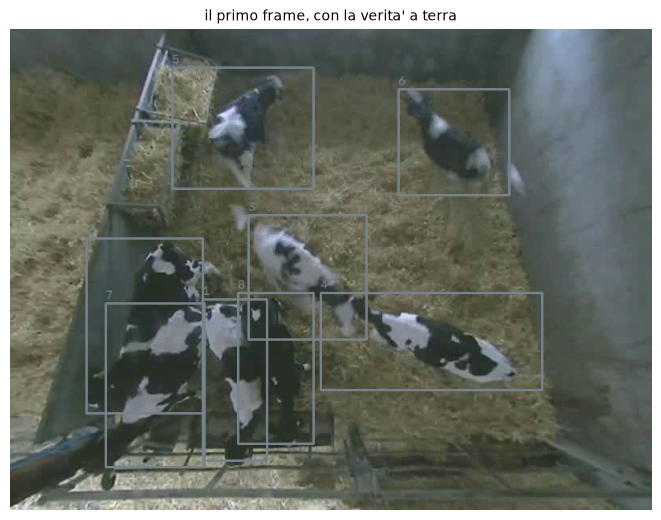

In [1]:
import pathlib, urllib.request, zipfile, io, importlib, subprocess, sys, os
import numpy as np, pandas as pd, cv2, matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

# PUNTO DI VARIAZIONE — la configurazione della pipeline
DETECTOR   = "yolo11m"   # yolo11n, yolo11s, yolo11m (AGPL-3.0) oppure rtdetr (Apache 2.0)
INGRESSO   = 640         # lato a cui il frame e' ricondotto per il modello
CONFIDENZA = 0.35        # soglia di esercizio: sotto, la detection viene scartata
SOVRAPP    = 0.60        # soglia della soppressione dei duplicati
DUE_PASSATE = True       # True: ByteTrack, usa anche le detection deboli. False: SORT
N_FRAME    = 300         # quanti frame elaborare, su 600. Abbassalo se la macchina e' lenta
X_LINEA    = 400.0       # la linea che gli oggetti attraversano, in pixel

D = pathlib.Path("dati-video")
if not (D / "clip.mp4").exists():
    U = "https://github.com/nunziati/zcs-ai-course-2026/releases/download/dati-video/8calves-clip.zip"
    with urllib.request.urlopen(U) as r: zipfile.ZipFile(io.BytesIO(r.read())).extractall(D)

L, A = 800, 600
B = ["x1", "y1", "x2", "y2"]
INK, MUTED, BLU, ROS = "#1f2933", "#77828c", "#2c5f8a", "#b8422f"
ANIMALI = {"cow", "dog", "bird", "sheep", "bear", "cat", "horse", "elephant", "zebra", "giraffe"}

vera = pd.read_csv(D / "clip-verita.csv")
vera["x1"] = (vera.x - vera.w / 2) * L; vera["y1"] = (vera.y - vera.h / 2) * A
vera["x2"] = (vera.x + vera.w / 2) * L; vera["y2"] = (vera.y + vera.h / 2) * A
vera = vera[vera.frame < N_FRAME]

def iou(a, b):
    x1 = np.maximum(a[:, None, 0], b[None, :, 0]); y1 = np.maximum(a[:, None, 1], b[None, :, 1])
    x2 = np.minimum(a[:, None, 2], b[None, :, 2]); y2 = np.minimum(a[:, None, 3], b[None, :, 3])
    dentro = np.clip(x2 - x1, 0, None) * np.clip(y2 - y1, 0, None)
    aa = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1]); bb = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return dentro / (aa[:, None] + bb[None, :] - dentro + 1e-9)

def nms(b, s, soglia):
    ordine = np.argsort(-s); tenuti = []
    while len(ordine):
        k = ordine[0]; tenuti.append(k)
        if len(ordine) == 1: break
        ordine = ordine[1:][iou(b[k:k + 1], b[ordine[1:]])[0] < soglia]
    return tenuti

def serve(modulo, pacchetto=None):
    try: return importlib.import_module(modulo)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pacchetto or modulo], check=True)
        return importlib.import_module(modulo)

# Il numero di thread cambia i tempi misurati anche di sei volte, e alcune librerie lo
# riscrivono quando le si importa. Fissarlo qui rende confrontabili le misure di sotto.
try:
    import torch
    THREAD = min(8, os.cpu_count() or 1)
    torch.set_num_threads(THREAD)
    print(f"core disponibili {os.cpu_count()}, thread fissati a {THREAD}"
          + (", GPU presente" if torch.cuda.is_available() else ", nessuna GPU"))
except ImportError:
    pass

print(f"{vera.frame.nunique()} frame, {len(vera)} bounding box annotati, "
      f"{vera.tracklet_id.nunique()} identita' vere")
print(f"configurazione: {DETECTOR}, ingresso {INGRESSO}, confidenza {CONFIDENZA}, "
      f"{'ByteTrack' if DUE_PASSATE else 'SORT'}")

c = cv2.VideoCapture(str(D / "clip.mp4")); ok, primo = c.read(); c.release()
mostra = primo.copy()
for _, q in vera[vera.frame == 0].iterrows():
    cv2.rectangle(mostra, (int(q.x1), int(q.y1)), (int(q.x2), int(q.y2)), (140, 130, 120), 2)
    cv2.putText(mostra, str(int(q.tracklet_id)), (int(q.x1), int(q.y1) - 5),
                cv2.FONT_HERSHEY_SIMPLEX, .5, (140, 130, 120), 1)
fig, ax = plt.subplots(figsize=(7, 5.3))
ax.imshow(cv2.cvtColor(mostra, cv2.COLOR_BGR2RGB)); ax.axis("off")
ax.set_title("il primo frame, con la verita' a terra", fontsize=10)
fig.tight_layout(); plt.show()

## 2 · Stadio 1 — decodifica

Dal file compresso ai frame. E' il primo costo, e non dipende dal modello.


In [2]:
import time

c = cv2.VideoCapture(str(D / "clip.mp4"))
frame, t_dec = [], []
for _ in range(N_FRAME):
    t0 = time.perf_counter()
    ok, im = c.read()
    t_dec.append(time.perf_counter() - t0)
    if not ok: break
    frame.append(im)
c.release()
t_dec = np.array(t_dec[:len(frame)])

memoria = sum(x.nbytes for x in frame) / 1e6
print(f"{len(frame)} frame decodificati")
print(f"tempo mediano per frame: {np.median(t_dec) * 1000:.2f} ms")
print(f"totale: {t_dec.sum():.2f} s   ->   {len(frame) / t_dec.sum():.0f} frame al secondo")
print(f"memoria occupata dai frame decompressi: {memoria:.0f} MB "
      f"({memoria / len(frame) * 1000:.0f} KB per frame)")
print(f"\nIl file compresso pesa {(D / 'clip.mp4').stat().st_size / 1e6:.1f} MB, "
      f"{memoria / ((D / 'clip.mp4').stat().st_size / 1e6):.0f} volte meno dei frame decompressi.")
print("I frame decompressi occupano memoria: una pipeline in esercizio ne tiene pochi alla")
print("volta, non tutta la sequenza.")

300 frame decodificati
tempo mediano per frame: 1.11 ms
totale: 0.38 s   ->   783 frame al secondo
memoria occupata dai frame decompressi: 432 MB (1440 KB per frame)

Il file compresso pesa 7.6 MB, 57 volte meno dei frame decompressi.
I frame decompressi occupano memoria: una pipeline in esercizio ne tiene pochi alla
volta, non tutta la sequenza.


## 3 · Stadio 2 — inferenza

Il modello, su ogni frame. Qui il tempo dipende dal modello e dalla risoluzione di ingresso.


In [3]:
if DETECTOR.startswith("yolo"):
    serve("ultralytics")
    from ultralytics import YOLO
    mod = YOLO(DETECTOR + ".pt")
    npar = sum(p.numel() for p in mod.model.parameters()) / 1e6
    def rileva(im):
        r = mod.predict(im, verbose=False, imgsz=INGRESSO, conf=0.10, iou=0.99, max_det=300)[0]
        return (r.boxes.xyxy.numpy(), r.boxes.conf.numpy(),
                [r.names[int(k)] for k in r.boxes.cls])
else:
    import torch
    from PIL import Image
    serve("transformers", "transformers>=4.47")
    from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
    CK = "PekingU/rtdetr_v2_r18vd"
    proc = RTDetrImageProcessor.from_pretrained(CK)
    mod = RTDetrV2ForObjectDetection.from_pretrained(CK).eval()
    npar = sum(p.numel() for p in mod.parameters()) / 1e6
    def rileva(im):
        img = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        with torch.no_grad():
            out = mod(**proc(images=img, return_tensors="pt",
                             size={"height": INGRESSO, "width": INGRESSO}))
        r = proc.post_process_object_detection(
            out, target_sizes=torch.tensor([[A, L]]), threshold=0.10)[0]
        return (r["boxes"].numpy(), r["scores"].numpy(),
                [mod.config.id2label[k.item()] for k in r["labels"]])

rileva(frame[0])                                   # riscaldamento
grezze, t_inf = [], []
for im in frame:
    t0 = time.perf_counter()
    grezze.append(rileva(im))
    t_inf.append(time.perf_counter() - t0)
t_inf = np.array(t_inf)

n_grezze = float(np.mean([len(g[0]) for g in grezze]))
print(f"{DETECTOR}: {npar:.1f} milioni di parametri, ingresso {INGRESSO}")
print(f"tempo mediano per frame: {np.median(t_inf) * 1000:.0f} ms   "
      f"->   {1 / np.median(t_inf):.1f} frame al secondo per il solo modello")
print(f"bounding box prodotti per frame, prima di qualunque filtro: {n_grezze:.1f}")
print(f"\nSono gia' {np.median(t_inf) / np.median(t_dec):.0f} volte il tempo della decodifica.")

yolo11m: 20.1 milioni di parametri, ingresso 640
tempo mediano per frame: 110 ms   ->   9.1 frame al secondo per il solo modello
bounding box prodotti per frame, prima di qualunque filtro: 47.6

Sono gia' 99 volte il tempo della decodifica.


## 4 · Stadio 3 — post-processing

Dalle uscite del modello alle detection: classe, soglia di confidenza, duplicati.


In [4]:
pulite, t_post = [], []
conta = {"grezze": 0, "dopo la classe": 0, "dopo la confidenza": 0, "dopo i duplicati": 0}
for b, s, n in grezze:
    t0 = time.perf_counter()
    conta["grezze"] += len(b)
    k = [i for i, q in enumerate(n) if q in ANIMALI]
    b, s = b[k], s[k]; conta["dopo la classe"] += len(b)
    k = s >= CONFIDENZA
    b, s = b[k], s[k]; conta["dopo la confidenza"] += len(b)
    if len(b):
        k = nms(b, s, SOVRAPP); b, s = b[k], s[k]
    conta["dopo i duplicati"] += len(b)
    pulite.append((b, s))
    t_post.append(time.perf_counter() - t0)
t_post = np.array(t_post)

print(f"soglia di confidenza {CONFIDENZA}, soppressione a {SOVRAPP}")
print(f"\n{'passo':>22}{'bounding box/frame':>21}")
for k, v in conta.items():
    print(f"{k:>22}{v / len(grezze):21.1f}")
print(f"\ntempo mediano del post-processing: {np.median(t_post) * 1000:.2f} ms per frame")
print(f"oggetti veri per frame: {len(vera) / vera.frame.nunique():.1f}")
print("\nIl post-processing costa poco e cambia molto: e' questo passo a fissare quanti")
print("oggetti il sistema dichiara di vedere.")

soglia di confidenza 0.35, soppressione a 0.6

                 passo   bounding box/frame
                grezze                 47.6
        dopo la classe                 47.5
    dopo la confidenza                 17.9
      dopo i duplicati                  4.5

tempo mediano del post-processing: 0.05 ms per frame
oggetti veri per frame: 7.9

Il post-processing costa poco e cambia molto: e' questo passo a fissare quanti
oggetti il sistema dichiara di vedere.


## 5 · Stadio 4 — tracking

Dalle detection alle tracce: ogni oggetto riceve un'identita' che dura nel tempo.


In [5]:
def traccia(pulite, grezze, due_passate, iou_min=0.3, max_persi=15, debole=0.15):
    tracce, prossimo, uscita = {}, 1, []

    def associa(ids, pred, box):
        if not len(ids) or not len(box): return [], list(range(len(box))), list(ids)
        M = iou(pred, box)
        r, q = linear_sum_assignment(-M)
        coppie = [(ids[i], j) for i, j in zip(r, q) if M[i, j] >= iou_min]
        liberi = [j for j in range(len(box)) if j not in [c[1] for c in coppie]]
        senza = [i for i in ids if i not in [c[0] for c in coppie]]
        return coppie, liberi, senza

    def aggiorna(i, nb):
        tracce[i]["v"] = 0.6 * tracce[i]["v"] + 0.4 * (nb - tracce[i]["b"])
        tracce[i]["b"] = nb; tracce[i]["persi"] = 0

    for f, ((forti, _), (gb, gs, gn)) in enumerate(zip(pulite, grezze)):
        k = [i for i, q in enumerate(gn) if q in ANIMALI]
        gb, gs = gb[k], gs[k]
        deboli = gb[(gs >= debole) & (gs < CONFIDENZA)] if due_passate else np.zeros((0, 4))
        ids = list(tracce)
        pred = np.array([tracce[i]["b"] + tracce[i]["v"] for i in ids]).reshape(-1, 4)
        coppie, liberi, senza = associa(ids, pred, forti)
        for i, j in coppie: aggiorna(i, forti[j])
        if due_passate and len(deboli) and senza:
            p2 = np.array([tracce[i]["b"] + tracce[i]["v"] for i in senza]).reshape(-1, 4)
            c2, _, senza = associa(senza, p2, deboli)
            for i, j in c2: aggiorna(i, deboli[j])
        for i in senza:
            tracce[i]["persi"] += 1; tracce[i]["b"] = tracce[i]["b"] + tracce[i]["v"]
        for j in liberi:
            tracce[prossimo] = {"b": forti[j], "v": np.zeros(4), "persi": 0}; prossimo += 1
        for i in [i for i in tracce if tracce[i]["persi"] > max_persi]: del tracce[i]
        for i in [i for i in tracce if tracce[i]["persi"] == 0]:
            uscita.append((f, i, *tracce[i]["b"]))
    return pd.DataFrame(uscita, columns=["frame", "id"] + B)

t0 = time.perf_counter()
tracce = traccia(pulite, grezze, DUE_PASSATE)
t_track = (time.perf_counter() - t0) / len(frame)

durata = tracce.groupby("id").size()
print(f"tracker: {'ByteTrack' if DUE_PASSATE else 'SORT'}")
print(f"identita' create: {tracce.id.nunique()}   identita' vere: {vera.tracklet_id.nunique()}")
print(f"durata delle tracce, in frame: mediana {durata.median():.0f}, "
      f"massima {durata.max()}, sotto i 10 frame {int((durata < 10).sum())}")
print(f"tempo mediano per frame: {t_track * 1000:.2f} ms")
print(f"\nOgni identita' in piu' rispetto a otto e' una traccia che si e' spezzata e ha")
print("ricominciato con un nome nuovo. Da qui in avanti quel numero e' l'errore.")

tracker: ByteTrack
identita' create: 47   identita' vere: 8
durata delle tracce, in frame: mediana 20, massima 235, sotto i 10 frame 12
tempo mediano per frame: 0.07 ms

Ogni identita' in piu' rispetto a otto e' una traccia che si e' spezzata e ha
ricominciato con un nome nuovo. Da qui in avanti quel numero e' l'errore.


## 6 · Stadio 5 — la regola di evento

Dalle tracce al numero che esce dal sistema: quanti attraversamenti della linea.


In [6]:
def attraversamenti(d, colonna_id, cx):
    eventi = []
    for i, g in d.assign(cx=cx).sort_values("frame").groupby(colonna_id):
        c = g.cx.values; f = g.frame.values
        cambi = (c[:-1] - X_LINEA) * (c[1:] - X_LINEA) < 0
        eventi += [(int(f[k + 1]), int(i)) for k in np.flatnonzero(cambi)]
    return sorted(eventi)

ev_veri = attraversamenti(vera, "tracklet_id", vera.x * L)
ev_sistema = attraversamenti(tracce, "id", (tracce.x1 + tracce.x2) / 2)

print(f"linea verticale a x = {X_LINEA:.0f} px, su {len(frame)} frame")
print(f"attraversamenti veri:      {len(ev_veri)}")
print(f"attraversamenti dichiarati: {len(ev_sistema)}   ({len(ev_sistema) - len(ev_veri):+d})")

# quanti eventi dichiarati cadono entro mezzo secondo da uno vero
tolleranza = 10
usati, giusti = set(), 0
for f_s, _ in ev_sistema:
    for k, (f_v, _) in enumerate(ev_veri):
        if k not in usati and abs(f_s - f_v) <= tolleranza:
            usati.add(k); giusti += 1; break
print(f"\ndi quelli dichiarati, entro mezzo secondo da uno vero: {giusti}")
print(f"inventati: {len(ev_sistema) - giusti}    mancati: {len(ev_veri) - giusti}")
print("\nQuesto e' il numero che il sistema consegna a chi lo usa. Nessuno degli errori")
print("degli stadi precedenti gli arriva in altra forma.")

linea verticale a x = 400 px, su 300 frame
attraversamenti veri:      25
attraversamenti dichiarati: 30   (+5)

di quelli dichiarati, entro mezzo secondo da uno vero: 23
inventati: 7    mancati: 2

Questo e' il numero che il sistema consegna a chi lo usa. Nessuno degli errori
degli stadi precedenti gli arriva in altra forma.


## 7 · Il tempo, stadio per stadio

Gli stadi messi in fila, e la frequenza che ne discende.


configurazione: yolo11m, ingresso 640, confidenza 0.35

            stadio   ms mediani    quota
        decodifica         1.11     1.0%   
         inferenza       109.89    98.9%   #######################################
   post-processing         0.05     0.0%   
          tracking         0.07     0.1%   
            totale       111.12     100%

frequenza sostenibile: 9.0 frame al secondo
lo stream ne porta venti al secondo: per reggerlo serve un fattore 2.2.

latenza per frame, in millisecondi:  media 112.1   mediana 111.4   99 pct 147.6


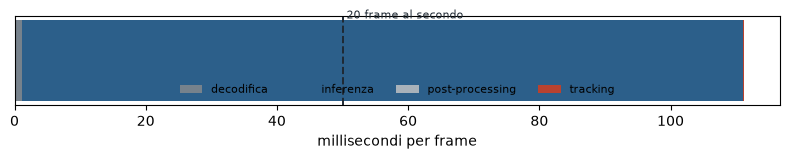

In [7]:
stadi = [("decodifica", np.median(t_dec)), ("inferenza", np.median(t_inf)),
         ("post-processing", np.median(t_post)), ("tracking", t_track)]
tot = sum(v for _, v in stadi)
per_frame = t_dec + t_inf + t_post + t_track

print(f"configurazione: {DETECTOR}, ingresso {INGRESSO}, confidenza {CONFIDENZA}")
print(f"\n{'stadio':>18}{'ms mediani':>13}{'quota':>9}")
for nome, v in stadi:
    print(f"{nome:>18}{v * 1000:13.2f}{v / tot:9.1%}   {'#' * int(v / tot * 40)}")
print(f"{'totale':>18}{tot * 1000:13.2f}{1:9.0%}")
print(f"\nfrequenza sostenibile: {1 / tot:.1f} frame al secondo")
print(f"lo stream ne porta venti al secondo: per reggerlo serve un fattore {20 * tot:.1f}.")
print(f"\nlatenza per frame, in millisecondi:  media {per_frame.mean() * 1000:.1f}   "
      f"mediana {np.median(per_frame) * 1000:.1f}   99 pct {np.percentile(per_frame, 99) * 1000:.1f}")

fig, ax = plt.subplots(figsize=(8, 1.7))
sinistra = 0
for (nome, v), col in zip(stadi, [MUTED, BLU, "#a9b2ba", ROS]):
    ax.barh(0, v * 1000, left=sinistra, color=col, label=nome); sinistra += v * 1000
ax.axvline(1000 / 20, ls="--", lw=1.4, color=INK)
ax.text(1000 / 20, .45, " 20 frame al secondo", fontsize=8, color=INK, va="center")
ax.set_yticks([]); ax.set_xlabel("millisecondi per frame")
ax.legend(frameon=False, fontsize=8, ncol=4, loc="lower center")
fig.tight_layout(); plt.show()

## 8 · La perdita di accuratezza lungo la catena

La stessa pipeline misurata a ogni stadio, contro la verita' a terra.


In [8]:
# stadio 3: le detection, confrontate una a una con gli oggetti veri
tp = fp = ng = 0
for f, (b, s) in enumerate(pulite):
    v = vera[vera.frame == f][B].values; ng += len(v)
    if len(b):
        m = iou(v, b); tp += int((m.max(1) >= 0.5).sum()); fp += int((m.max(0) < 0.5).sum())
rich_det, prec_det = tp / ng, tp / max(tp + fp, 1)

# stadio 4: le tracce, contro le identita' vere
ultimo, scambi, abbinati = {}, 0, 0
for f, v in vera.groupby("frame"):
    p = tracce[tracce.frame == f]
    if not len(p): continue
    M = iou(v[B].values, p[B].values)
    r, q = linear_sum_assignment(-M)
    for i, j in zip(r, q):
        if M[i, j] < 0.5: continue
        abbinati += 1
        g = int(v.tracklet_id.values[i]); pid = int(p.id.values[j])
        if g in ultimo and ultimo[g] != pid: scambi += 1
        ultimo[g] = pid

print(f"{'stadio':>26}{'quello che misura':>22}{'valore':>10}")
print(f"{'3 · detection':>26}{'richiamo':>22}{rich_det:10.2f}")
print(f"{'3 · detection':>26}{'precisione':>22}{prec_det:10.2f}")
print(f"{'4 · tracking':>26}{'identita create':>22}{tracce.id.nunique():10d}")
print(f"{'4 · tracking':>26}{'scambi di identita':>22}{scambi:10d}")
print(f"{'5 · evento':>26}{'attraversamenti veri':>22}{len(ev_veri):10d}")
print(f"{'5 · evento':>26}{'dichiarati':>22}{len(ev_sistema):10d}")

errore = abs(len(ev_sistema) - len(ev_veri)) / max(len(ev_veri), 1)
print(f"\nIl detector trova {rich_det:.0%} degli oggetti e sbaglia {1 - prec_det:.0%} delle")
print(f"detection che dichiara. Il numero finale sbaglia del {errore:.0%}.")
print("Le due percentuali non si deducono l'una dall'altra: fra le due c'e' il tracking,")
print("che puo' compensare un oggetto mancato e puo' moltiplicare un errore. La misura che")
print("conta e' l'ultima, e deve essere fatta sulla catena intera.")

                    stadio     quello che misura    valore
             3 · detection              richiamo      0.44
             3 · detection            precisione      0.76
              4 · tracking       identita create        47
              4 · tracking    scambi di identita       128
                5 · evento  attraversamenti veri        25
                5 · evento            dichiarati        30

Il detector trova 44% degli oggetti e sbaglia 24% delle
detection che dichiara. Il numero finale sbaglia del 20%.
Le due percentuali non si deducono l'una dall'altra: fra le due c'e' il tracking,
che puo' compensare un oggetto mancato e puo' moltiplicare un errore. La misura che
conta e' l'ultima, e deve essere fatta sulla catena intera.


## 9 · Progettare a partire dal vincolo

Dato un limite di tempo, quali configurazioni ci stanno e quanto costano in accuratezza.


In [9]:
# il tempo di ciascun modello, misurato una volta su pochi frame
LIMITE = 1000 / 20                                   # millisecondi disponibili per frame
tempi = {}
for nome in ("yolo11n", "yolo11s", "yolo11m", "rtdetr"):
    if nome.startswith("yolo"):
        serve("ultralytics")
        from ultralytics import YOLO
        try:
            import torch; torch.set_num_threads(min(8, os.cpu_count() or 1))
        except ImportError: pass
        m = YOLO(nome + ".pt")
        f = lambda im: m.predict(im, verbose=False, imgsz=INGRESSO, conf=0.25)
    else:
        try:
            import torch
            from PIL import Image
            serve("transformers", "transformers>=4.47")
            from transformers import RTDetrV2ForObjectDetection, RTDetrImageProcessor
            p_ = RTDetrImageProcessor.from_pretrained("PekingU/rtdetr_v2_r18vd")
            m_ = RTDetrV2ForObjectDetection.from_pretrained("PekingU/rtdetr_v2_r18vd").eval()
            def f(im):
                img = Image.fromarray(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
                with torch.no_grad():
                    m_(**p_(images=img, return_tensors="pt",
                            size={"height": INGRESSO, "width": INGRESSO}))
        except Exception as e:
            print("rtdetr non disponibile:", e); continue
    f(frame[0])
    t = [ ]
    for im in frame[:8]:
        t0 = time.perf_counter(); f(im); t.append(time.perf_counter() - t0)
    tempi[nome] = float(np.median(t)) * 1000

fisso = (np.median(t_dec) + np.median(t_post) + t_track) * 1000
print(f"limite: {LIMITE:.0f} ms per frame (venti al secondo)")
print(f"costo fisso della pipeline, senza il modello: {fisso:.1f} ms")
print(f"\n{'modello':>10}{'licenza':>12}{'ms modello':>12}{'ms totali':>11}"
      f"{'frame/s':>11}{'entra':>8}{'attraversamenti':>17}")
LIC = {"yolo11n": "AGPL-3.0", "yolo11s": "AGPL-3.0", "yolo11m": "AGPL-3.0", "rtdetr": "Apache 2.0"}
esiti = {}
for nome, ms in tempi.items():
    # stessi stadi 3, 4 e 5 di sopra, sulle detection gia' calcolate di questo modello
    det = pd.read_csv(D / ("det-" + nome + ".csv"))
    det = det[det.classe.isin(ANIMALI) & (det.frame < N_FRAME)]
    g_alt, p_alt = [], []
    for f_ in range(len(frame)):
        d = det[det.frame == f_]
        b, sc = d[B].values, d.conf.values
        g_alt.append((b, sc, ["cow"] * len(b)))
        k = sc >= CONFIDENZA; b2, s2 = b[k], sc[k]
        if len(b2):
            k2 = nms(b2, s2, SOVRAPP); b2, s2 = b2[k2], s2[k2]
        p_alt.append((b2, s2))
    tr = traccia(p_alt, g_alt, DUE_PASSATE)
    n = attraversamenti(tr, "id", (tr.x1 + tr.x2) / 2)
    tot_ms = ms + fisso
    esiti[nome] = (tot_ms, len(n))
    print(f"{nome:>10}{LIC[nome]:>12}{ms:12.0f}{tot_ms:11.0f}"
          f"{1000 / tot_ms:11.1f}{('si' if tot_ms <= LIMITE else 'no'):>8}{len(n):17d}")
print(f"\nattraversamenti veri: {len(ev_veri)}")

dentro = {k: v for k, v in esiti.items() if v[0] <= LIMITE}
print("\nI modelli candidati sono quelli che entrano nel tempo disponibile, e l'accuratezza")
print("sceglie dentro quella lista.")
if not dentro:
    print("Qui non entra nessuno, e restano due strade: una macchina piu' veloce, oppure")
    print("elaborare un frame ogni due o tre, accettando che fra un'elaborazione e l'altra il")
    print("sistema non veda niente.")
else:
    peggiore = min(dentro.items(), key=lambda kv: abs(kv[1][1] - len(ev_veri)))
    fuori = {k: v for k, v in esiti.items() if v[0] > LIMITE}
    print(f"Dei modelli che entrano nel limite, il migliore sul conteggio e' {peggiore[0]}, che")
    print(f"dichiara", end=" ")
    print(f"{peggiore[1][1]} attraversamenti contro {len(ev_veri)}.", end=" ")
    if fuori:
        mig = min(fuori.items(), key=lambda kv: abs(kv[1][1] - len(ev_veri)))
        print(f"Fuori dal limite ci sono modelli piu' accurati")
        print(f"— {mig[0]} ne dichiara {mig[1][1]} — e per usarli restano due strade: elaborare un frame")
        print(f"ogni {int(np.ceil(mig[1][0] / LIMITE))}, oppure una macchina piu' veloce.")
    else:
        print()
print("\nIn ogni caso la licenza taglia la lista prima ancora dell'accuratezza: se il")
print("progetto non puo' essere AGPL-3.0, delle quattro righe ne resta una.")

/home/giacomo/.claude/jobs/8a0e74f8/tmp/v4/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/529 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 529/529 [00:00<00:00, 14005.28it/s]

limite: 50 ms per frame (venti al secondo)
costo fisso della pipeline, senza il modello: 1.2 ms

   modello     licenza  ms modello  ms totali    frame/s   entra  attraversamenti
   yolo11n    AGPL-3.0          18         19       53.1      si               16


   yolo11s    AGPL-3.0          40         41       24.5      si               21
   yolo11m    AGPL-3.0         112        113        8.8      no               28


    rtdetr  Apache 2.0         156        157        6.4      no               83

attraversamenti veri: 25

I modelli candidati sono quelli che entrano nel tempo disponibile, e l'accuratezza
sceglie dentro quella lista.
Dei modelli che entrano nel limite, il migliore sul conteggio e' yolo11s, che
dichiara 21 attraversamenti contro 25. Fuori dal limite ci sono modelli piu' accurati
— yolo11m ne dichiara 28 — e per usarli restano due strade: elaborare un frame
ogni 3, oppure una macchina piu' veloce.

In ogni caso la licenza taglia la lista prima ancora dell'accuratezza: se il
progetto non puo' essere AGPL-3.0, delle quattro righe ne resta una.


## 10 · Le tracce sui frame

Le identita' assegnate dal tracker, disegnate a distanza di qualche secondo.


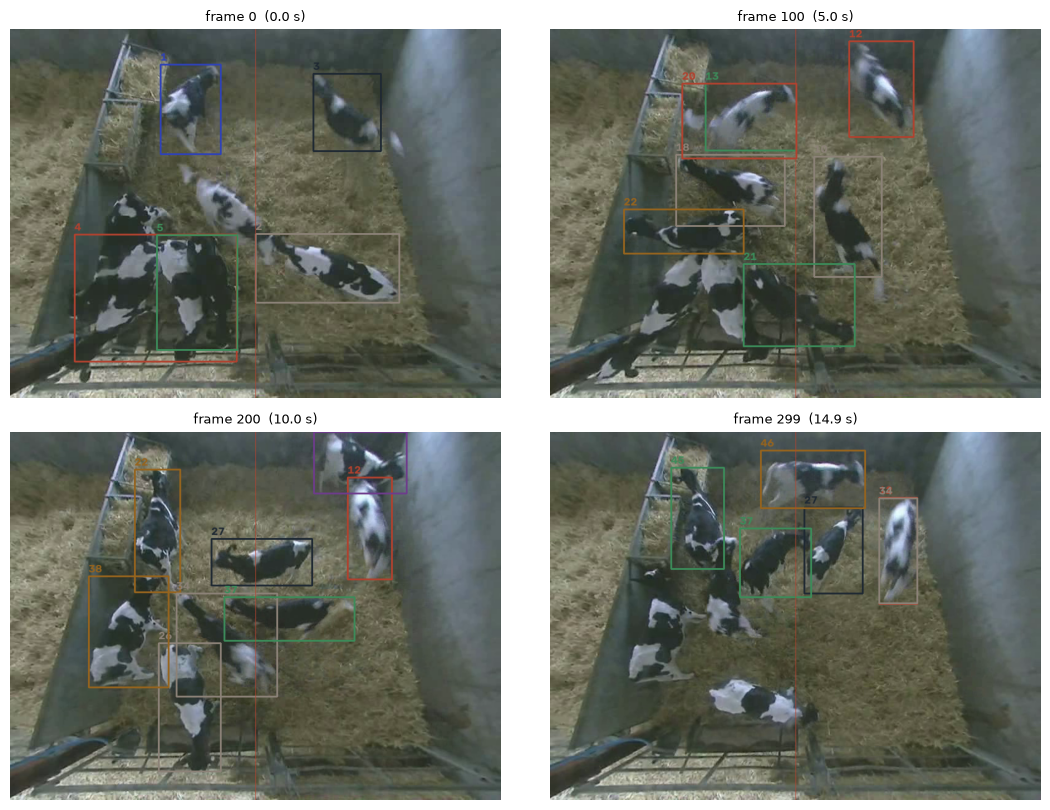

Il numero sopra ogni bounding box e' l'identita' assegnata dal tracker. Se un numero
cambia da un pannello all'altro sullo stesso animale, quella traccia si e' spezzata,
e l'attraversamento successivo verra' contato come nuovo.


In [10]:
COLORI = [(44, 95, 138), (47, 66, 184), (140, 130, 120), (31, 41, 51),
          (176, 66, 47), (60, 140, 90), (150, 100, 30), (110, 60, 140)]
scelti = [k for k in (0, len(frame) // 3, 2 * len(frame) // 3, len(frame) - 1)]
fig, ax = plt.subplots(2, 2, figsize=(11, 8.2))
for a, f_ in zip(ax.ravel(), scelti):
    im = frame[f_].copy()
    for _, q in tracce[tracce.frame == f_].iterrows():
        col = COLORI[int(q.id) % len(COLORI)]
        cv2.rectangle(im, (int(q.x1), int(q.y1)), (int(q.x2), int(q.y2)), col[::-1], 2)
        cv2.putText(im, str(int(q.id)), (int(q.x1), int(q.y1) - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, .6, col[::-1], 2)
    cv2.line(im, (int(X_LINEA), 0), (int(X_LINEA), A), (47, 66, 184), 1)
    a.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB)); a.axis("off")
    a.set_title(f"frame {f_}  ({f_ / 20:.1f} s)", fontsize=9)
fig.tight_layout(); plt.show()

print("Il numero sopra ogni bounding box e' l'identita' assegnata dal tracker. Se un numero")
print("cambia da un pannello all'altro sullo stesso animale, quella traccia si e' spezzata,")
print("e l'attraversamento successivo verra' contato come nuovo.")